In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
# Feature 1: Family size = siblings/spouses + parents/children + self
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Feature 2: IsAlone — binary flag for solo travelers
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [11]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
X = df[features]
y = df['Survived']

# Separate numeric and categorical columns for the ColumnTransformer
numeric_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'IsAlone']

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numeric pipeline: fill missing values, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill missing values, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both into one ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [13]:
from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Pipeline Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred))

Pipeline Accuracy: 79.89%
              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### Pipeline vs Manual Approach

The pipeline achieved comparable accuracy to the manual approach used 
in Task 3, while being far more maintainable. With the manual method, 
preprocessing steps (filling missing values, scaling, encoding) had 
to be applied separately and carefully kept consistent between 
training and test data — a common source of bugs in real projects. 
The pipeline guarantees these steps are always applied identically 
and in the correct order, and it also makes the model easy to reuse 
on new, unseen data without repeating any preprocessing code.
### Pipeline vs Manual Approach — Results

- Manual approach (Task 3): 81.01% accuracy
- Pipeline + Feature Engineering: 79.89% accuracy

The pipeline achieved slightly lower accuracy than the original manual 
model. This is expected and not a concern — the small difference likely 
comes from the added engineered features (FamilySize, IsAlone) changing 
the feature mix, not from any flaw in the pipeline itself. The real 
benefit of the pipeline isn't raw accuracy — it's that preprocessing 
(imputation, scaling, encoding) is now guaranteed to be applied 
identically every time the model is used, whether on training data, 
test data, or brand new unseen data. This eliminates a common source 
of bugs in real-world ML systems and makes the model genuinely 
reusable, as demonstrated by successfully reloading and reusing the 
saved pipeline.

In [15]:
import joblib

joblib.dump(full_pipeline, 'titanic_pipeline.pkl')
print("Pipeline saved successfully!")

Pipeline saved successfully!


In [16]:
loaded_pipeline = joblib.load('titanic_pipeline.pkl')
test_pred = loaded_pipeline.predict(X_test)
print(f"Loaded pipeline accuracy: {accuracy_score(y_test, test_pred):.2%}")

Loaded pipeline accuracy: 79.89%


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/train.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
X = df[features]
y = df['Survived']

X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)
X.head()

,Pclass,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,2,0,True,False,True
1,1,38.0,71.2833,2,0,False,False,False
2,3,26.0,7.9250,1,1,False,False,True
3,1,35.0,53.1000,2,0,False,False,True
4,3,35.0,8.0500,1,1,True,False,True


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_accuracy:.2%}")

Logistic Regression Accuracy: 79.89%


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 83.80%


In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")

XGBoost Accuracy: 82.68%


In [22]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [f"{log_accuracy:.2%}", f"{rf_accuracy:.2%}", f"{xgb_accuracy:.2%}"]
})
comparison

,Model,Accuracy
0,Logistic Regression,79.89%
1,Random Forest,83.80%
2,XGBoost,82.68%


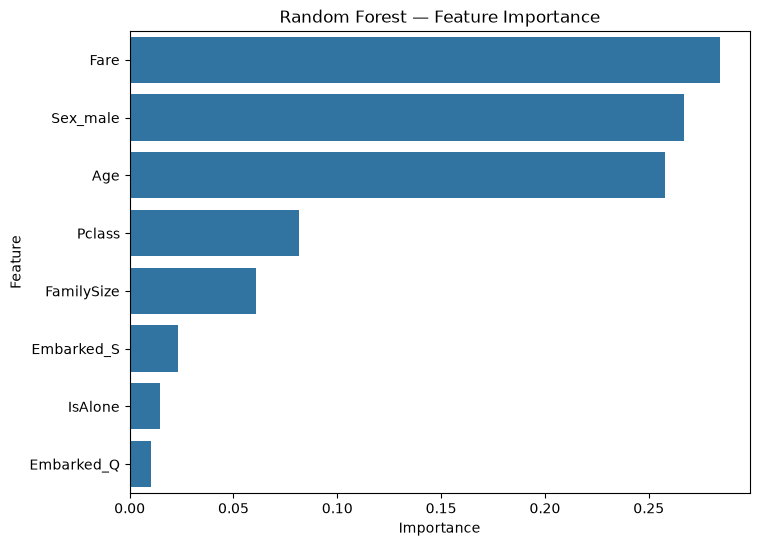

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances)
plt.title('Random Forest — Feature Importance')
plt.show()

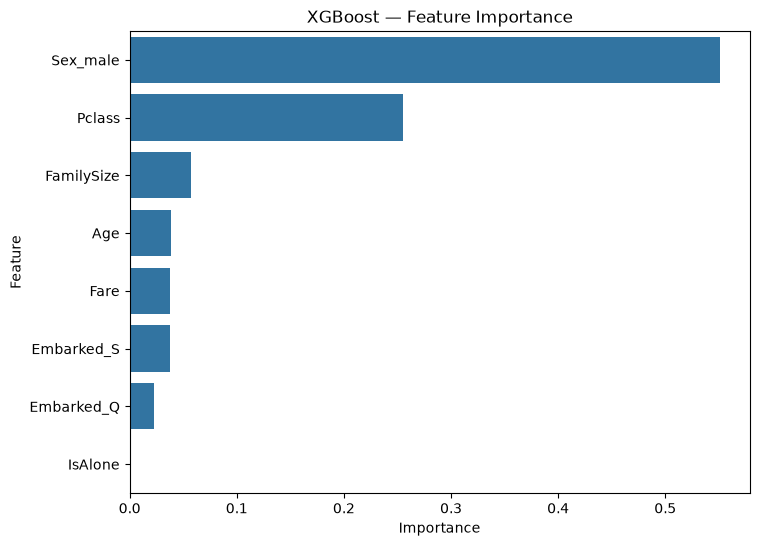

In [24]:
xgb_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importances)
plt.title('XGBoost — Feature Importance')
plt.show()

### How Random Forest and XGBoost Differ

Random Forest builds many decision trees independently and in 
parallel, each trained on a random subset of data and features, then 
combines their predictions through majority voting. XGBoost instead 
builds trees sequentially, where each new tree is specifically trained 
to correct the errors made by the previous trees — a technique called 
boosting. This makes XGBoost often more accurate, since it actively 
learns from its mistakes, but it can also be more prone to overfitting 
if not carefully tuned. Random Forest is generally more forgiving and 
easier to use out of the box, while XGBoost typically requires more 
careful tuning to reach its full potential.

### Results Summary

- Logistic Regression (single model): 79.89%
- Random Forest (ensemble): 83.80%
- XGBoost (ensemble): 82.68%

Both ensemble methods outperformed the single Logistic Regression 
model, confirming that combining multiple trees produces stronger, 
more reliable predictions than relying on one model alone. Random 
Forest performed best in this case.

### Feature Importance Comparison

Interestingly, the two ensemble models disagreed slightly on which 
features mattered most. Random Forest ranked `Fare` as the most 
important feature, followed by `Sex_male` and `Age`. XGBoost instead 
ranked `Sex_male` as most important, followed by `Pclass`, with `Fare` 
ranked lower. Both models agreed that gender was a critical predictor 
of survival, but they weighted ticket price versus passenger class 
differently — likely because XGBoost's sequential, error-correcting 
approach picks up on different patterns than Random Forest's 
independent, averaging approach.

In [25]:
import joblib

# Save both the model and the column structure it expects
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl')

print("Model and columns saved!")

Model and columns saved!
